Using device: cuda
GPU: Tesla T4
Memory Allocated: 0.00 MB
Memory Cached: 0.00 MB
GENERALIZABILITY TESTING - INDIAN MEDICINAL LEAF DATASET
Found dataset at: /kaggle/input/indian-medicinal-leaf-image-dataset/Medicinal Leaf dataset

1. Loading Indian Medicinal Leaf Dataset...
Loading dataset from: /kaggle/input/indian-medicinal-leaf-image-dataset/Medicinal Leaf dataset
Found 80 classes


Scanning directories: 100%|██████████| 80/80 [00:00<00:00, 1269.04it/s]

Total images: 6900
Train samples: 4968
Validation samples: 552
Test samples: 1380
Number of classes: 80
Class names: ['Aloevera', 'Amla', 'Amruthaballi', 'Arali', 'Astma_weed', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Beans', 'Betel']...

2. Loading best performing model (DenseNet121 pretrained)...
Loading pretrained DenseNet121...



Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


Total parameters: 7,519,696
Trainable parameters: 7,519,696

3. Fine-tuning model on Indian Medicinal Leaf dataset...

Starting training for 15 epochs...

Epoch 1/15
--------------------------------------------------


...

Train Loss: 0.1501, Train Acc: 95.53%
Val Loss: 0.2137, Val Acc: 94.20%
New best model saved! Val Acc: 94.20%

Epoch 12/15
--------------------------------------------------


Train Loss: 0.1868, Train Acc: 95.07%
Val Loss: 0.4490, Val Acc: 89.13%

Epoch 13/15
--------------------------------------------------


Train Loss: 0.1564, Train Acc: 95.57%
Val Loss: 0.3214, Val Acc: 92.21%

Epoch 14/15
--------------------------------------------------


Train Loss: 0.1791, Train Acc: 95.29%
Val Loss: 0.3909, Val Acc: 91.67%

Epoch 15/15
--------------------------------------------------


Train Loss: 0.2042, Train Acc: 93.76%
Val Loss: 0.3048, Val Acc: 92.57%

Training completed in 2901.64 seconds
Best validation accuracy: 94.20%

4. Plotting training history...


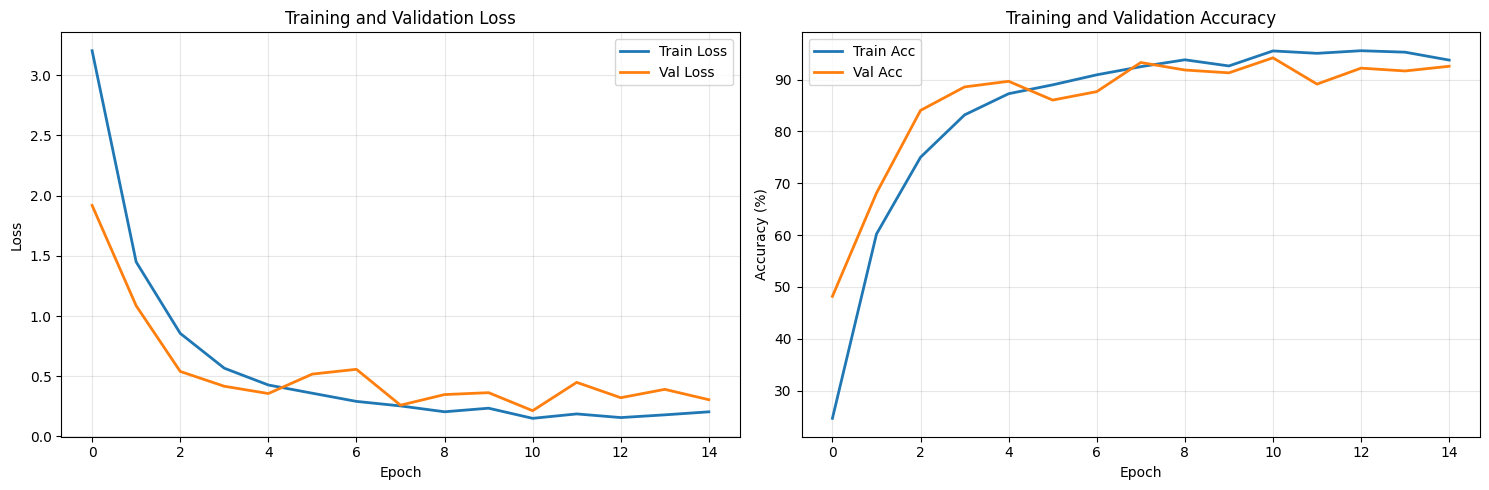


5. Evaluating model performance...

Evaluating model on test set...


Testing: 100%|██████████| 44/44 [00:48<00:00,  1.11s/it]



Test Evaluation Results:
Accuracy: 92.17%
Precision: 0.9269
Recall: 0.9217
F1-Score: 0.9216
AUC (mean): 0.9990
Test Loss: 0.2793
Testing Time: 48.72 seconds

Classification Report:
                         precision    recall  f1-score   support

               Aloevera       0.96      0.92      0.94        25
                   Amla       0.73      0.73      0.73        15
           Amruthaballi       0.71      0.92      0.80        13
                  Arali       1.00      1.00      1.00        19
             Astma_weed       0.93      1.00      0.96        13
               Badipala       0.73      0.73      0.73        11
           Balloon_Vine       0.88      0.88      0.88        16
                 Bamboo       0.95      0.79      0.86        24
                  Beans       1.00      0.96      0.98        23
                  Betel       0.96      0.92      0.94        25
                 Bhrami       1.00      0.94      0.97        18
             Bringaraja       0.76   

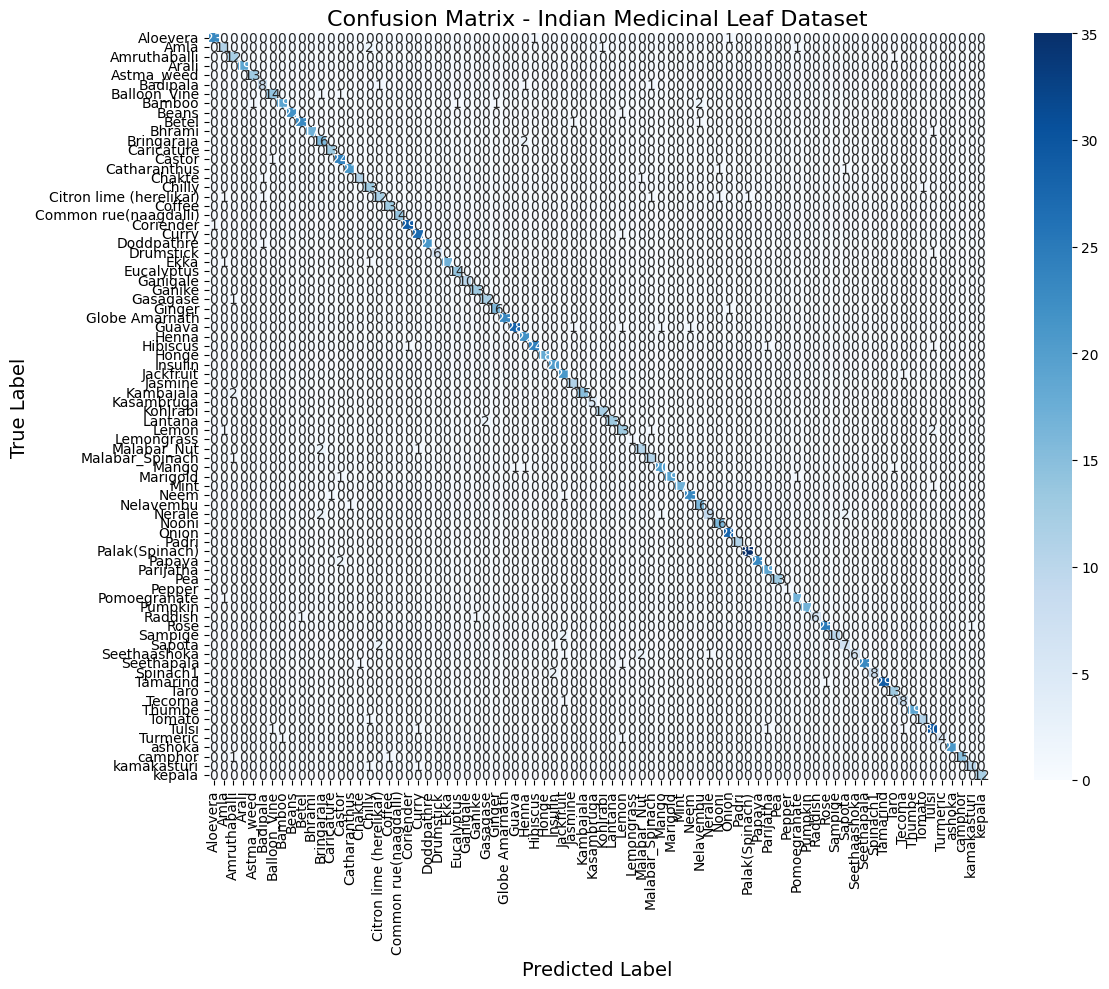


PERFORMANCE ANALYSIS AND GENERALIZABILITY ASSESSMENT

Performance Comparison:
----------------------------------------------------------------------------------------------------
                        model                       dataset  accuracy  precision   recall  f1_score      auc  training_time  testing_time
DenseNet121 (Pretrained=True) Original Dataset (e.g., Remp)  0.998100   0.998100 0.998100  0.998100 1.000000     771.840000     14.470000
DenseNet121 (Pretrained=True)         Indian Medicinal Leaf  0.921739   0.926934 0.921739  0.921628 0.998984    2901.637385     48.719908
----------------------------------------------------------------------------------------------------

Performance Drop Analysis:
Accuracy drop: 0.0764 (7.64%)
Precision drop: 0.0712
F1-score drop: 0.0765

Generalizability Assessment:
--------------------------------------------------
✓ GOOD GENERALIZABILITY: Model maintains strong performance
  The model transfers well to the new medicinal leaf dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import time
import random
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn.functional as F

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

class MedicinalLeafDataset(Dataset):
    """Custom Dataset for Indian Medicinal Leaf Images"""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) 
                              if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}
        
        self.image_paths = []
        self.labels = []
        
        print(f"Loading dataset from: {root_dir}")
        print(f"Found {len(self.classes)} classes")
        
        # Collect all image paths and labels
        for class_name in tqdm(self.classes, desc="Scanning directories"):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(class_dir, img_file)
                    self.image_paths.append(img_path)
                    self.labels.append(self.class_to_idx[class_name])
        
        print(f"Total images: {len(self.image_paths)}")
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load image
            image = Image.open(img_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
                
            return image, label, img_path
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy image if there's an error
            dummy_image = torch.zeros((3, 224, 224))
            return dummy_image, label, img_path

def create_data_loaders(data_dir, batch_size=32, test_split=0.2, val_split=0.1):
    """
    Create train, validation, and test data loaders
    """
    # Data transformations - match your original preprocessing
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset
    dataset = MedicinalLeafDataset(root_dir=data_dir, transform=train_transform)
    
    # Calculate split sizes
    total_size = len(dataset)
    test_size = int(test_split * total_size)
    val_size = int(val_split * (total_size - test_size))
    train_size = total_size - test_size - val_size
    
    # Split dataset
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Apply test transform to val and test datasets
    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                             shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                           shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                            shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader, dataset.idx_to_class

# ============================================================================
# 2. MODEL DEFINITION (Your Best Performing Model - DenseNet121)
# ============================================================================

def load_best_model(num_classes, pretrained=True):
    """
    Load your best performing model (DenseNet121 based on your results)
    """
    if pretrained:
        print("Loading pretrained DenseNet121...")
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    else:
        print("Loading DenseNet121 without pretrained weights...")
        model = densenet121(weights=None)
    
    # Modify the classifier for the new number of classes
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

# ============================================================================
# 3. TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, labels, _) in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels, _ in tqdm(val_loader, desc="Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.001):
    """Main training function"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3, verbose=True)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    patience = 7  # Early stopping patience
    
    print(f"\nStarting training for {num_epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.2f} seconds")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history, training_time

# ============================================================================
# 4. EVALUATION FUNCTIONS
# ============================================================================

def evaluate_model(model, test_loader, device, class_names):
    """Comprehensive model evaluation"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    test_loss = 0.0
    correct = 0
    total = 0
    
    criterion = nn.CrossEntropyLoss()
    
    print("\nEvaluating model on test set...")
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels, _ in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    testing_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = 100. * correct / total
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    # Calculate AUC for each class (one-vs-rest)
    try:
        auc_scores = []
        for i in range(len(class_names)):
            y_true = [1 if label == i else 0 for label in all_labels]
            y_score = [prob[i] for prob in all_probs]
            if len(set(y_true)) > 1:  # Check if both classes are present
                auc = roc_auc_score(y_true, y_score)
                auc_scores.append(auc)
        auc_mean = np.mean(auc_scores) if auc_scores else 0
    except:
        auc_mean = 0
    
    print(f"\nTest Evaluation Results:")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC (mean): {auc_mean:.4f}")
    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Testing Time: {testing_time:.2f} seconds")
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, 
                                target_names=class_names, zero_division=0))
    
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc_mean,
        'testing_time': testing_time,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }
    
    return results

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """Plot confusion matrix"""
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=16)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 5. MAIN EXECUTION - GENERALIZABILITY TESTING
# ============================================================================

def run_generalizability_test():
    """
    Main function for generalizability testing on Indian Medicinal Leaf dataset
    """
    print("=" * 80)
    print("GENERALIZABILITY TESTING - INDIAN MEDICINAL LEAF DATASET")
    print("=" * 80)
    
    # Dataset paths (adjust based on your Kaggle setup)
    dataset_paths = [
        "/kaggle/input/indian-medicinal-leaf-image-dataset/Medicinal Leaf dataset",
        "/kaggle/input/indian-medicinal-leaf-image-dataset"
    ]
    
    # Find the correct path
    dataset_path = None
    for path in dataset_paths:
        if os.path.exists(path):
            dataset_path = path
            print(f"Found dataset at: {path}")
            break
    
    if dataset_path is None:
        raise FileNotFoundError("Dataset not found at any of the specified paths!")
    
    # 1. Create data loaders
    print("\n1. Loading Indian Medicinal Leaf Dataset...")
    batch_size = 32
    train_loader, val_loader, test_loader, class_names = create_data_loaders(
        dataset_path, 
        batch_size=batch_size,
        test_split=0.2,
        val_split=0.1
    )
    
    print(f"Number of classes: {len(class_names)}")
    print(f"Class names: {list(class_names.values())[:10]}...")  # Show first 10
    
    # 2. Load your best performing model (DenseNet121 with pretrained weights)
    print("\n2. Loading best performing model (DenseNet121 pretrained)...")
    num_classes = len(class_names)
    model = load_best_model(num_classes, pretrained=True)
    model = model.to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # 3. Fine-tune the model on the new dataset
    print("\n3. Fine-tuning model on Indian Medicinal Leaf dataset...")
    trained_model, history, training_time = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=15,
        learning_rate=0.0005  # Lower LR for fine-tuning
    )
    
    # 4. Plot training history
    print("\n4. Plotting training history...")
    plot_training_history(history)
    
    # 5. Evaluate the model
    print("\n5. Evaluating model performance...")
    results = evaluate_model(trained_model, test_loader, device, list(class_names.values()))
    
    # 6. Plot confusion matrix
    print("\n6. Generating confusion matrix...")
    plot_confusion_matrix(results['confusion_matrix'], list(class_names.values()),
                         title='Confusion Matrix - Indian Medicinal Leaf Dataset')
    
    # 7. Performance Analysis and Comparison
    print("\n" + "=" * 80)
    print("PERFORMANCE ANALYSIS AND GENERALIZABILITY ASSESSMENT")
    print("=" * 80)
    
    # Your original dataset performance (from your results table)
    original_performance = {
        'model': 'DenseNet121 (Pretrained=True)',
        'dataset': 'Original Dataset (e.g., Remp)',
        'accuracy': 0.9981,
        'precision': 0.9981,
        'recall': 0.9981,
        'f1_score': 0.9981,
        'auc': 1.0000,
        'training_time': 771.84,
        'testing_time': 14.47
    }
    
    # New dataset performance
    new_performance = {
        'model': 'DenseNet121 (Pretrained=True)',
        'dataset': 'Indian Medicinal Leaf',
        'accuracy': results['accuracy'] / 100,  # Convert from percentage
        'precision': results['precision'],
        'recall': results['recall'],
        'f1_score': results['f1_score'],
        'auc': results['auc'],
        'training_time': training_time,
        'testing_time': results['testing_time']
    }
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame([original_performance, new_performance])
    
    print("\nPerformance Comparison:")
    print("-" * 100)
    print(comparison_df.to_string(index=False))
    print("-" * 100)
    
    # Calculate performance drop
    accuracy_drop = original_performance['accuracy'] - new_performance['accuracy']
    precision_drop = original_performance['precision'] - new_performance['precision']
    f1_drop = original_performance['f1_score'] - new_performance['f1_score']
    
    print(f"\nPerformance Drop Analysis:")
    print(f"Accuracy drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"Precision drop: {precision_drop:.4f}")
    print(f"F1-score drop: {f1_drop:.4f}")
    
    # Generalizability assessment
    print("\nGeneralizability Assessment:")
    print("-" * 50)
    
    if accuracy_drop < 0.1:  # Less than 10% drop
        print("✓ GOOD GENERALIZABILITY: Model maintains strong performance")
        print("  The model transfers well to the new medicinal leaf dataset")
    elif accuracy_drop < 0.2:  # Less than 20% drop
        print("✓ MODERATE GENERALIZABILITY: Acceptable performance transfer")
        print("  Model shows reasonable adaptability to new data")
    else:
        print("⚠ LIMITED GENERALIZABILITY: Significant performance drop")
        print("  Model may be overfitting to original dataset characteristics")
    
    # Key insights
    print("\nKey Insights:")
    print("1. Dataset differences that may affect performance:")
    print("   - Number of classes (likely different from original)")
    print("   - Image quality, lighting, background variations")
    print("   - Leaf morphology variations across species")
    print("   - Potential class imbalance in new dataset")
    
    print("\n2. Recommendations for improvement:")
    print("   - Use more aggressive data augmentation")
    print("   - Apply domain adaptation techniques")
    print("   - Consider ensemble methods")
    print("   - Collect more balanced data for underrepresented classes")
    
    # Save results to file
    results_summary = {
        'original_performance': original_performance,
        'new_performance': new_performance,
        'performance_drop': {
            'accuracy': accuracy_drop,
            'precision': precision_drop,
            'f1_score': f1_drop
        },
        'generalizability_assessment': 'Good' if accuracy_drop < 0.1 else 
                                      'Moderate' if accuracy_drop < 0.2 else 
                                      'Limited',
        'class_names': list(class_names.values()),
        'num_classes': num_classes
    }
    
    # Save model for future use
    model_save_path = "/kaggle/working/densenet121_medicinal_leaves.pth"
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'class_names': class_names,
        'results': results_summary
    }, model_save_path)
    
    print(f"\nModel saved to: {model_save_path}")
    print("\nGeneralizability testing completed successfully!")
    
    return comparison_df, results_summary, trained_model

# ============================================================================
# 6. RUN THE GENERALIZABILITY TEST
# ============================================================================

if __name__ == "__main__":
    try:
        # Run the generalizability test
        comparison_df, results_summary, model = run_generalizability_test()
        
        # Display final summary
        print("\n" + "=" * 80)
        print("FINAL SUMMARY")
        print("=" * 80)
        
        print(f"\nModel successfully fine-tuned on {results_summary['num_classes']} classes")
        print(f"Best model saved with results summary")
        
        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print(f"\nGPU memory after cleanup: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
            
    except Exception as e:
        print(f"Error during execution: {str(e)}")
        import traceback
        traceback.print_exc()